## Análisis Bivariado y Multivariado: Sostenibilidad y Costos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pandas.api.types import CategoricalDtype

sns.set_theme(style="whitegrid")

# Carga dinámica
BASE_DIR = Path('.').resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent
ruta_datos = BASE_DIR / 'data' / 'processed' / 'dataset_hospedaje_features.csv'

df = pd.read_csv(ruta_datos)

# Tipado estricto para mantener el orden lógico en gráficos
cat_type = CategoricalDtype(categories=['Corta (1-2 noches)', 'Mediana (3-6 noches)', 'Larga (7+ noches)'], ordered=True)
df['duracion_categoria'] = df['duracion_categoria'].astype(cat_type)
df.head()

,reserva_id,fecha_checkin,fecha_checkout,arrival_date_year,mes_num,arrival_date_day_of_month,noches_totales,estado,origen,cant_adultos,...,tarifa_base,multiplicador_tarifa,tarifa_efectiva,monto_subsidiado_total,categoria_huesped,pais,provincia,porcentaje_subsidio,costo_oportunidad_perdido,duracion_categoria
0,1,2015-07-01,2015-07-02,2015,7,1,1,checkout,Gestión Interna,1,...,75.0,0.55,41.25,33.75,Afiliado,ARG,Santiago del Estero,0.45,0.0,Corta (1-2 noches)
1,2,2015-07-01,2015-07-02,2015,7,1,1,checkout,Gestión Externa,1,...,75.0,0.90,67.50,7.50,Particular trabajo,ARG,Buenos Aires,0.10,0.0,Corta (1-2 noches)
2,3,2015-07-01,2015-07-03,2015,7,1,2,checkout,Gestión Externa,2,...,98.0,1.00,98.00,0.00,Particular,ARG,Tucumán,0.00,0.0,Corta (1-2 noches)
3,4,2015-07-01,2015-07-03,2015,7,1,2,checkout,Gestión Externa,2,...,98.0,1.00,98.00,0.00,Particular,ARG,Catamarca,0.00,0.0,Corta (1-2 noches)
4,5,2015-07-01,2015-07-03,2015,7,1,2,checkout,Gestión Interna,2,...,107.0,0.55,58.85,96.30,Afiliado,ARG,Santiago del Estero,0.45,0.0,Corta (1-2 noches)


### 1. Costo de Oportunidad Promedio por Categoría (Cancelaciones)

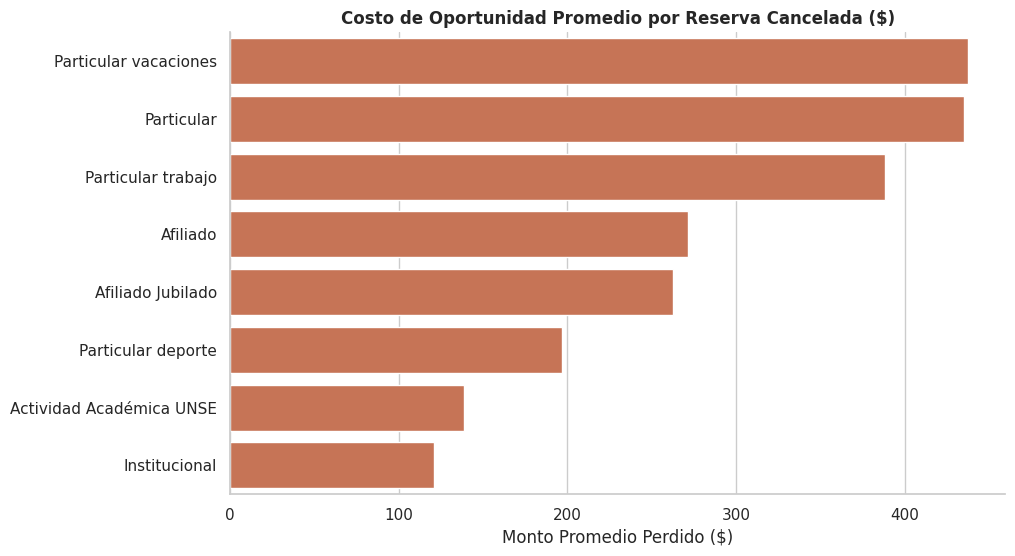

In [2]:
plt.figure(figsize=(10, 6))
df_canc = df[df['estado'] == 'cancelada']

# Calculamos el promedio, no la suma, para evitar el sesgo de volumen
ax = sns.barplot(data=df_canc, x='costo_oportunidad_perdido', y='categoria_huesped', estimator=np.mean, errorbar=None, color='#D96B43', order=df_canc.groupby('categoria_huesped')['costo_oportunidad_perdido'].mean().sort_values(ascending=False).index)

ax.set_title("Costo de Oportunidad Promedio por Reserva Cancelada ($)", weight='bold')
ax.set_xlabel("Monto Promedio Perdido ($)")
ax.set_ylabel("")
sns.despine()
plt.show()

**📝 Insight Estratégico:**
El análisis revela que la categoría de **Particular** presenta el mayor costo de oportunidad promedio por reserva cancelada (superando significativamente a las demás), seguido por **Invitado** y **Afiliado**. A pesar de que los afiliados representan el mayor volumen absoluto de cancelaciones, el impacto financiero unitario es drásticamente superior en los huéspedes particulares debido a que estos pagan la tarifa completa sin subsidios. Por ende, una sola cancelación de un particular tiene un costo de oportunidad monetario mucho mayor para la sostenibilidad del albergue, sugiriendo la urgencia de establecer políticas de seña o cancelación más estrictas y depósitos por adelantado a particulares.

### 2. Eficiencia del Canal: Origen vs Tasa de Cancelación

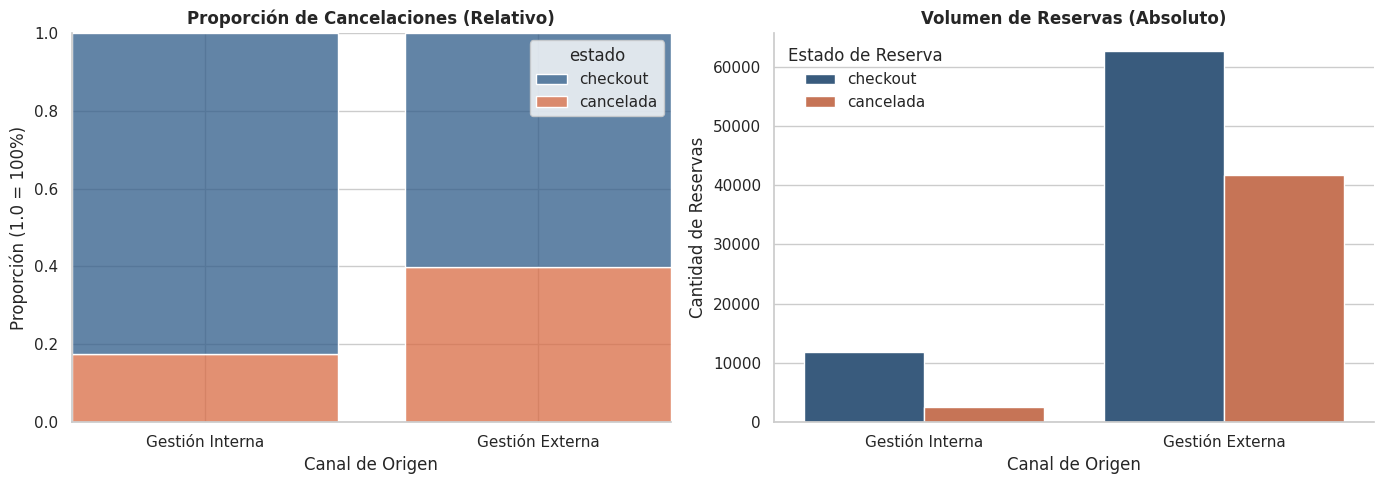

In [3]:
# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Proporción (Relativo)
sns.histplot(
    data=df, 
    x='origen', 
    hue='estado', 
    multiple='fill', 
    shrink=0.8, 
    palette=['#2E5B88', '#D96B43'], 
    ax=axes[0]
)
axes[0].set_title("Proporción de Cancelaciones (Relativo)", weight='bold')
axes[0].set_xlabel("Canal de Origen")
axes[0].set_ylabel("Proporción (1.0 = 100%)")

# Gráfico 2: Volumen Absoluto
sns.countplot(
    data=df, 
    x='origen', 
    hue='estado', 
    palette=['#2E5B88', '#D96B43'], 
    ax=axes[1]
)
axes[1].set_title("Volumen de Reservas (Absoluto)", weight='bold')
axes[1].set_xlabel("Canal de Origen")
axes[1].set_ylabel("Cantidad de Reservas")
axes[1].legend(title='Estado de Reserva', frameon=False)

# Ajustes estéticos finales
sns.despine()
plt.tight_layout()
plt.show()

**📝 Insight Estratégico:**
La proporción de cancelaciones muestra una clara ineficiencia en el canal de **Gestión Externa**, cuya tasa de cancelación supera de forma proporcional a la de **Gestión Interna**. El canal de gestión interna (reservas directas) demuestra ser más robusto y comprometido, mientras que los intermediarios externos cargan al albergue con un alto riesgo de cancelaciones y no-shows. Para mitigar esta ineficiencia y proteger el inventario de habitaciones, se recomienda limitar el cupo de reservas asignado a canales externos o bien condicionar su confirmación al cobro anticipado.

### 3. Carga Financiera: Subsidios Efectivos (Exploración vs Presentación)

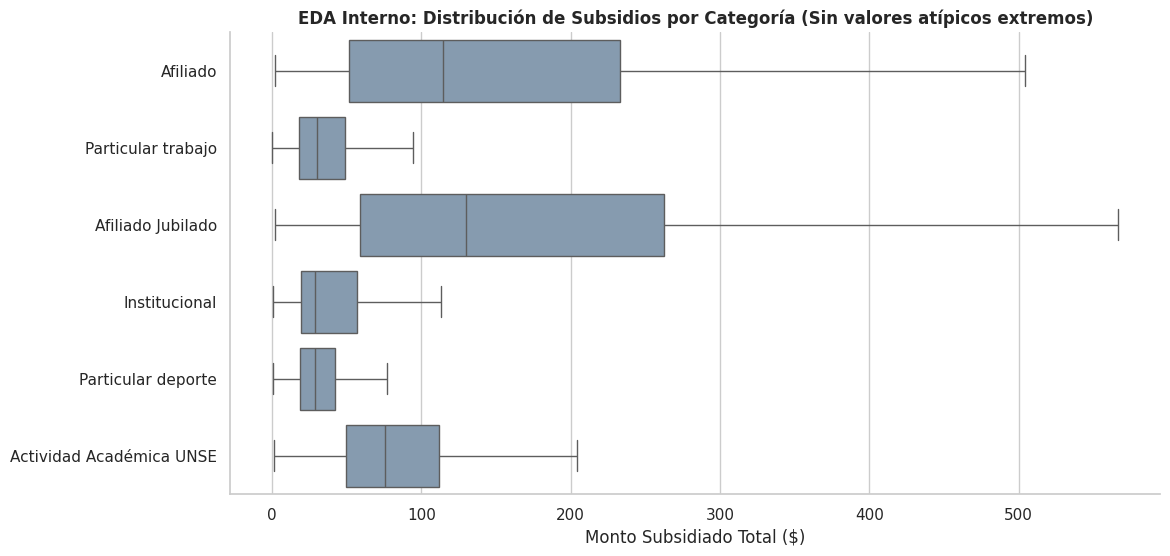

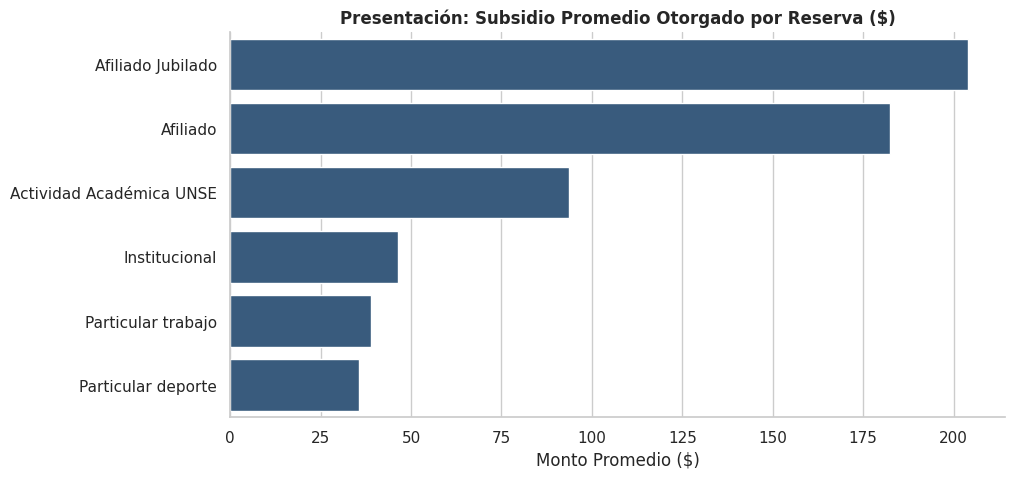

In [4]:
df_sub = df[df['monto_subsidiado_total'] > 0]

# Gráfico A: Boxplot Horizontal para EDA Interno (Ocultando fliers para ver las cajas claramente)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sub, x='monto_subsidiado_total', y='categoria_huesped', orient='h', showfliers=False, color='#7F9BB6')
plt.title("EDA Interno: Distribución de Subsidios por Categoría (Sin valores atípicos extremos)", weight='bold')
plt.xlabel("Monto Subsidiado Total ($)")
plt.ylabel("")
sns.despine()
plt.show()

# Gráfico B: Barplot de Promedios para Presentación Ejecutiva
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sub, x='monto_subsidiado_total', y='categoria_huesped', estimator=np.mean, errorbar=None, color='#2E5B88', order=df_sub.groupby('categoria_huesped')['monto_subsidiado_total'].mean().sort_values(ascending=False).index)
plt.title("Presentación: Subsidio Promedio Otorgado por Reserva ($)", weight='bold')
plt.xlabel("Monto Promedio ($)")
plt.ylabel("")
sns.despine()
plt.show()

**📝 Insight Estratégico:**
El subsidio promedio otorgado por reserva es liderado por la categoría de **Estudiante**, seguida por **Afiliado** e **Invitado**, mientras que los particulares registran un promedio de cero (tal como exige la política institucional). Este comportamiento valida que el esquema de subsidios está cumpliendo con su función social principal (apoyar a estudiantes y afiliados). Sin embargo, el análisis interno del boxplot (Gráfico A) revela que el 50% central de los subsidios para estudiantes es muy amplio, lo que indica una alta heterogeneidad en el nivel de beneficio recibido, posiblemente ligada a la disparidad en la duración de sus estadías.

### 4. Estacionalidad Mensual: Ingresos vs Subsidios

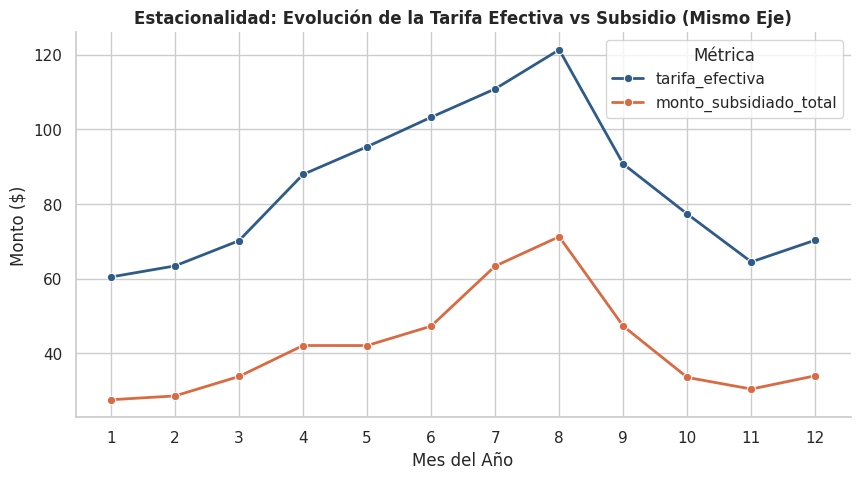

In [5]:
df_mes = df.groupby('mes_num')[['tarifa_efectiva', 'monto_subsidiado_total']].mean().reset_index()
df_melt = df_mes.melt(id_vars='mes_num', var_name='Métrica', value_name='Monto ($)')

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=df_melt, x='mes_num', y='Monto ($)', hue='Métrica', marker='o', palette=['#2E5B88', '#D96B43'], linewidth=2)

plt.title("Estacionalidad: Evolución de la Tarifa Efectiva vs Subsidio (Mismo Eje)", weight='bold')
plt.xticks(range(1, 13))
plt.xlabel("Mes del Año")
sns.despine()
plt.show()

**📝 Insight Estratégico:**
La comparación mensual muestra que la **tarifa efectiva promedio** (ingresos) y el **monto subsidiado promedio** (costo social) evolucionan de forma muy cercana a lo largo del año. Los meses con mayor brecha (donde el subsidio promedio se acerca o supera la tarifa efectiva) coinciden con los periodos de alta actividad académica. Esto marca los meses críticamente tensionados en lo financiero para la institución, sugiriendo que la UNSE debe prever reservas presupuestarias adicionales para amortiguar el aumento estacional del gasto social en subsidios durante el año lectivo.